# Modelado y predicción

En este notebook se entrenan, validan y comparan diferentes modelos para predecir la temperatura promedio mensual de Guatemala.


--- TRANSFORMACIÓN DE LA SERIE ---
Datos originales: 882
Datos transformados: 870
Diferenciación aplicada: 12 meses


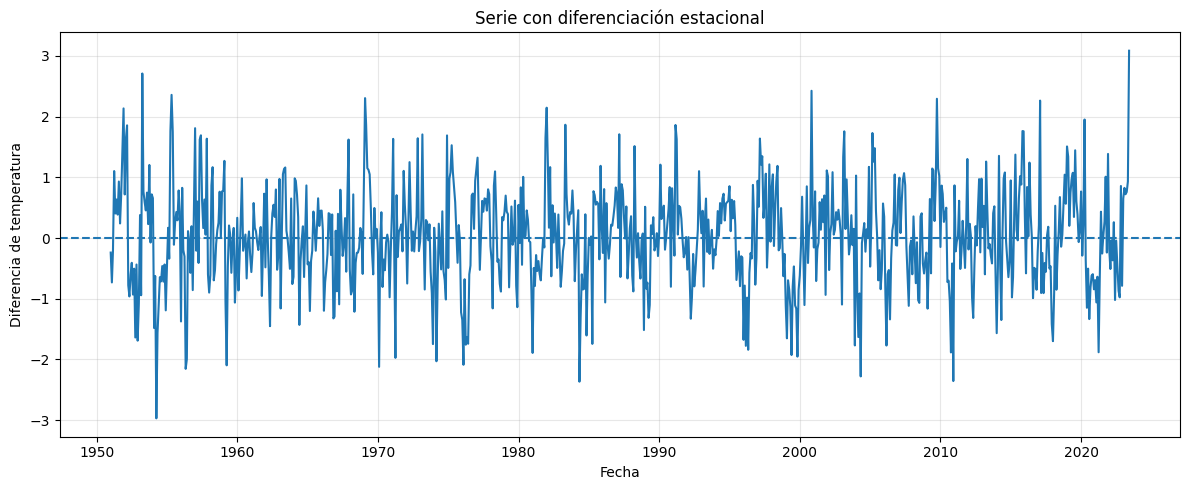


--- ADF DESPUÉS DE LA TRANSFORMACIÓN ---
Estadístico: -7.9423
Valor p: 0.0
La serie es estacionaria según ADF.

--- KPSS DESPUÉS DE LA TRANSFORMACIÓN ---
Estadístico: 0.0126
Valor p: 0.1
La serie es estacionaria según KPSS.


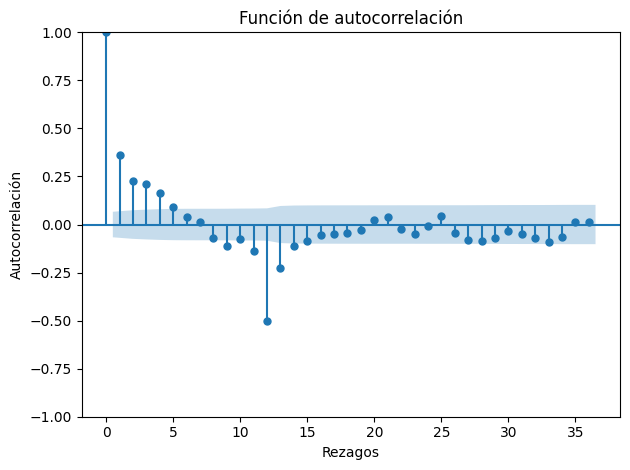

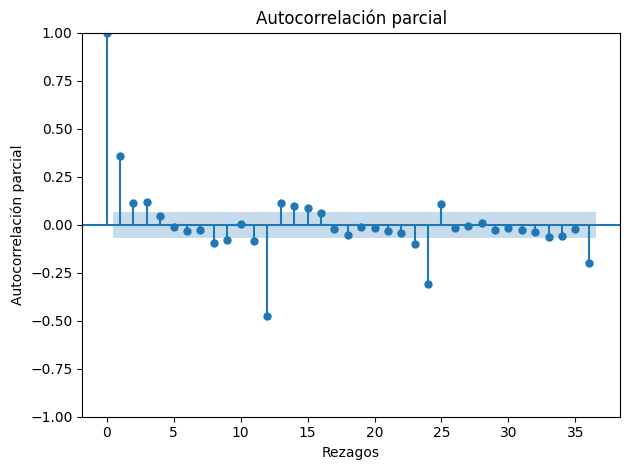


--- ENTRENAMIENTO DE MODELOS ---

Modelo: modelo_1
Orden: (1, 0, 1)
Orden estacional: (0, 1, 1, 12)
AIC: 1403.8626
BIC: 1427.624
Convergencia: True

Modelo: modelo_2
Orden: (2, 0, 0)
Orden estacional: (0, 1, 1, 12)
AIC: 1418.0678
BIC: 1441.835
Convergencia: True

Modelo: modelo_3
Orden: (0, 0, 2)
Orden estacional: (0, 1, 1, 12)
AIC: 1428.8387
BIC: 1452.5942
Convergencia: True

--- MEJOR MODELO ---
Modelo: modelo_1
AIC: 1403.8626
BIC: 1427.624

Resultados guardados correctamente.


In [1]:
# Transformación y modelos SARIMA
%run ../src/04_modelos_arima.py


--- MODELO SELECCIONADO ---
Modelo: modelo_1
Orden: (1, 0, 1)
Orden estacional: (0, 1, 1, 12)
AIC: 1403.8626
BIC: 1427.624

--- COEFICIENTES ---
coeficiente     valor       p_valor  significativo
  intercept  0.003761  6.229856e-04           True
      ar.L1  0.766506  3.602832e-48           True
      ma.L1 -0.502336  6.379027e-13           True
   ma.S.L12 -0.956296  0.000000e+00           True
     sigma2  0.290841 6.545437e-114           True

Todos los coeficientes son significativos.

--- RAÍCES DEL MODELO ---
tipo    parte_real  parte_imaginaria   modulo  fuera_circulo_unitario
  AR  1.304621e+00          0.000000 1.304621                    True
  MA -1.003731e+00         -0.000000 1.003731                    True
  MA -8.692564e-01         -0.501865 1.003731                    True
  MA -8.692564e-01          0.501865 1.003731                    True
  MA -5.018654e-01         -0.869256 1.003731                    True
  MA -5.018654e-01          0.869256 1.003731            

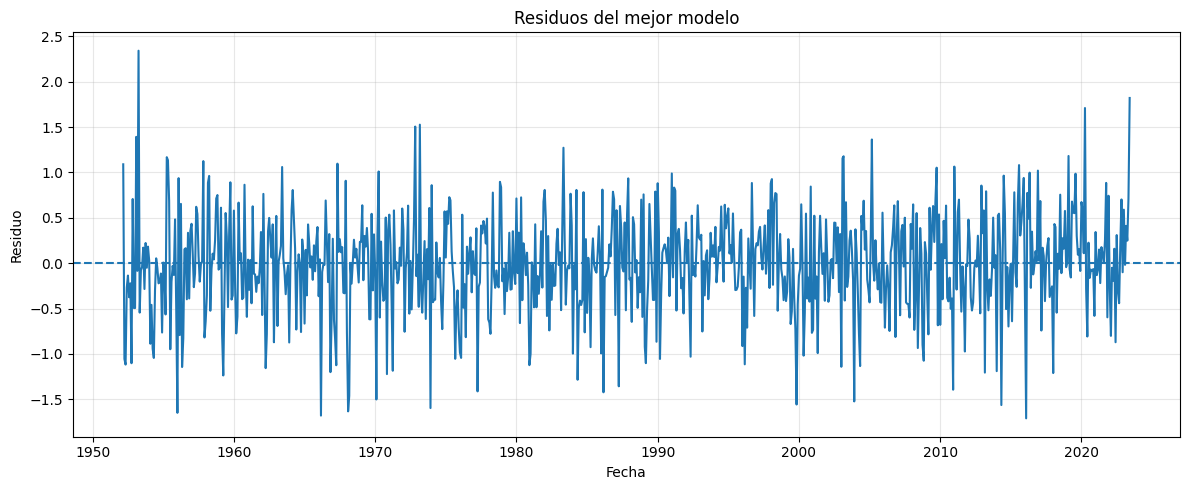

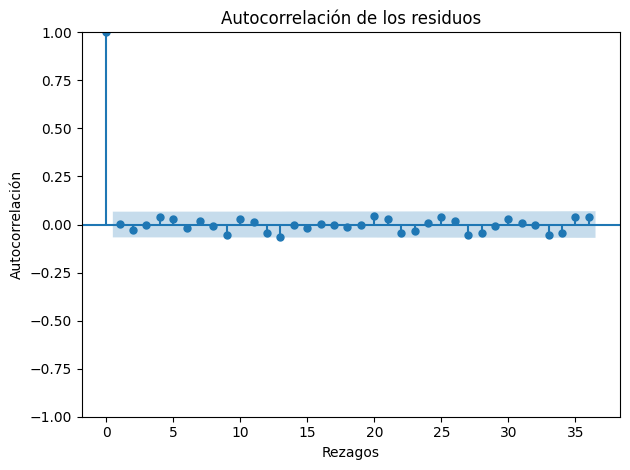

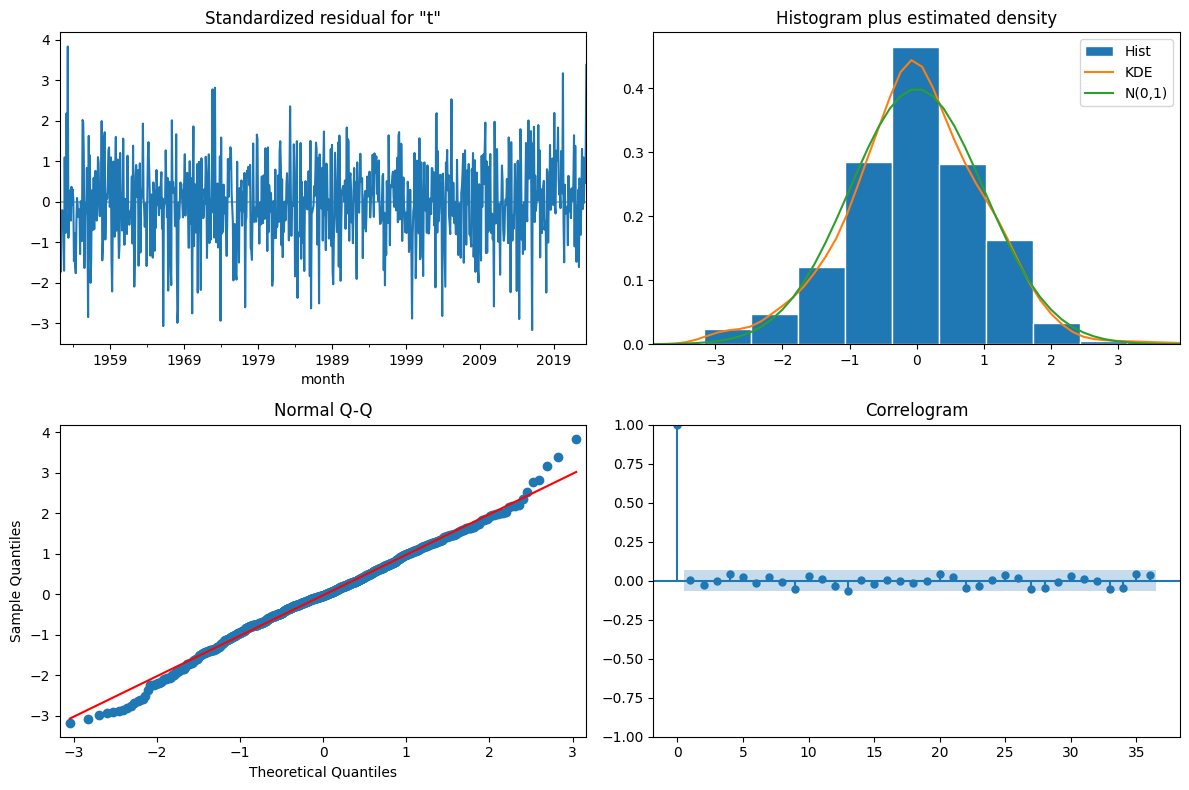


--- PRUEBA LJUNG-BOX ---
 rezago  estadistico  p_valor
     12     8.188111 0.515306
     24    17.251509 0.695752
     36    31.627999 0.535386

Los residuos no presentan autocorrelación significativa.

Resultados guardados correctamente.


In [2]:
# Validación del mejor modelo
%run ../src/05_validacion.py


--- PREDICCIÓN SARIMA ---
Modelo utilizado: modelo_1
MAE: 0.6191
RMSE: 0.8637
MAPE: 2.5176 %


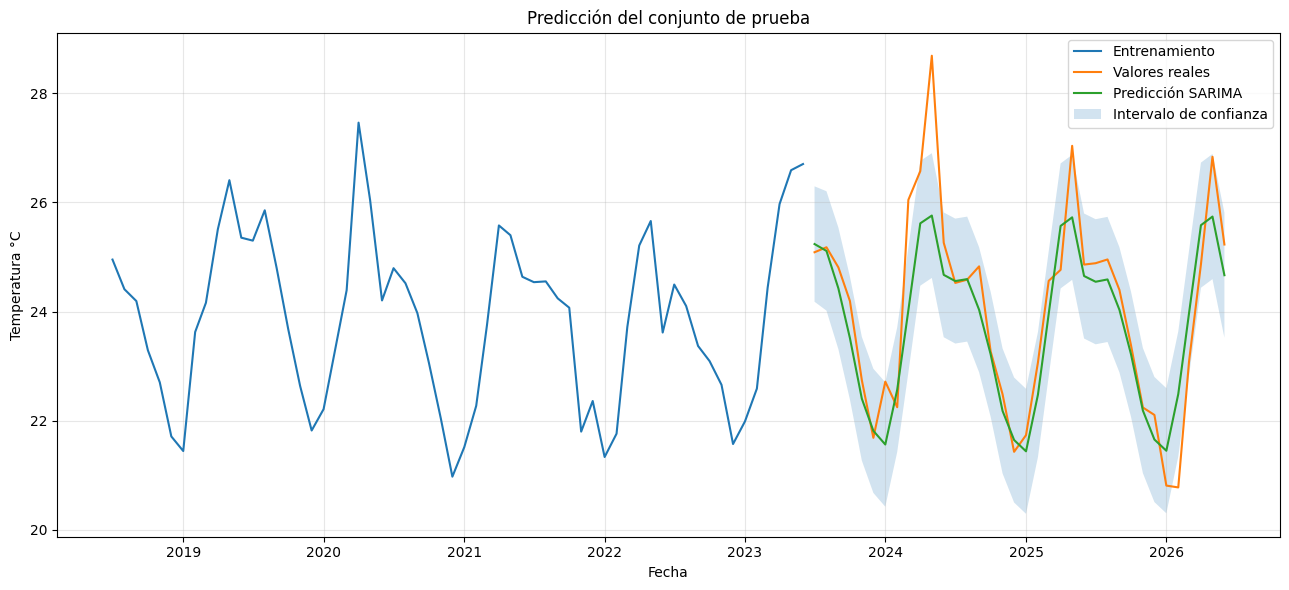


Resultados guardados correctamente.


In [3]:
# Predicción del conjunto de prueba
%run ../src/06_prediccion.py


--- COMPARACIÓN DE MODELOS ---
                   modelo      MAE     RMSE      MAPE
          SARIMA modelo_1 0.619124 0.863737  2.517597
             Holt-Winters 0.730457 0.944264  3.102934
           Seasonal naive 0.797325 0.987170  3.278206
Suavizamiento exponencial 2.784409 3.205041 12.115834

Mejor modelo según RMSE: SARIMA modelo_1


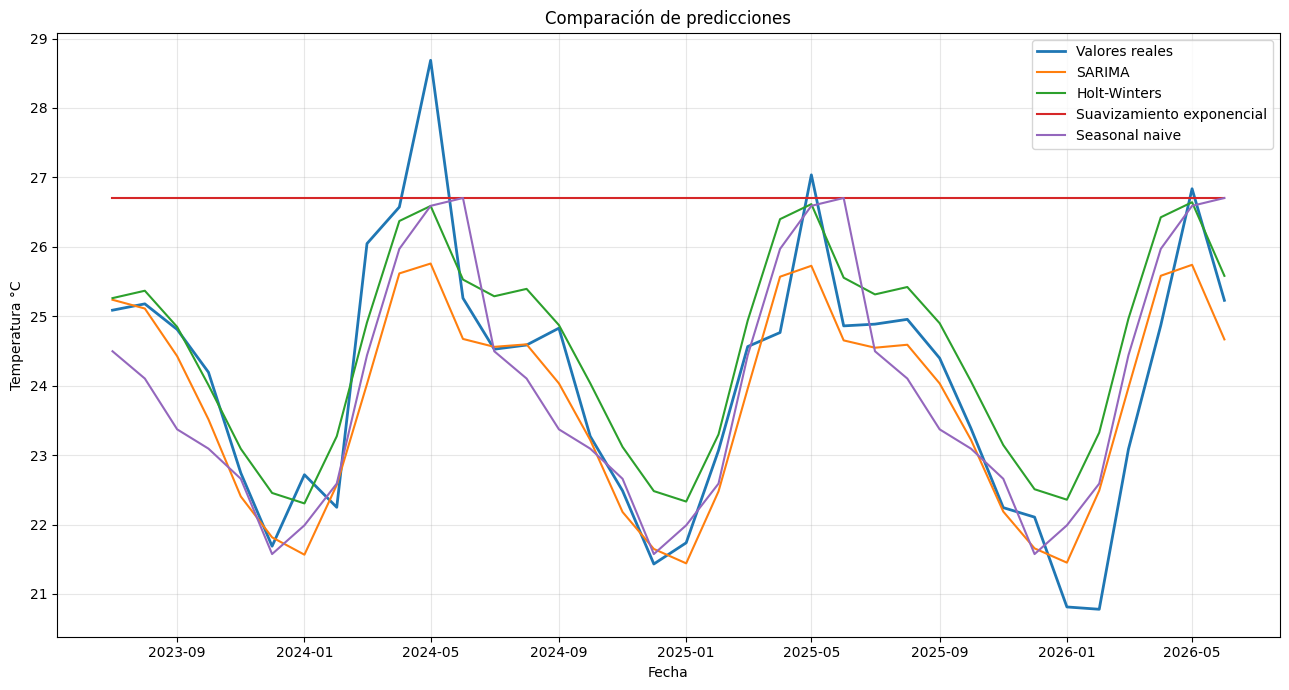


Resultados guardados correctamente.


In [4]:
# Comparación con otros modelos
%run ../src/07_modelos_alternativos.py